<a href="https://colab.research.google.com/github/lakshmi220/Perfect-Roadmap-To-Learn-Data-Science-In-2024/blob/main/Classification_Models_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification Models: From Binary Diagnosis to Multiclass Prediction

---

> ### 📋 Practice Exercise. Not Graded.
> This is a **practice assignment** for self-assessment. The marks shown throughout are **indicative only**. They tell you where to spend your effort and where you might need more practice. **None of these marks count towards your final grade.**
>
> Attempt every section. Compare your results. Revisit what trips you up.

---

## What You Will Build

Two classifiers, two datasets, one progression from simple to complex.

| Part | Dataset | Task | Primary Metric |
|------|---------|------|----------------|
| **Part 1** | Breast Cancer (sklearn) | Binary: Malignant vs Benign | Recall (Sensitivity) |
| **Part 2** | Wine (sklearn) | Multiclass: 3 wine cultivars | Macro-averaged F1-Score |

**Indicative Marks: 100** (Part 1: 55 | Part 2: 45)

### Before You Start
- Complete all cells marked with `# TODO`.
- Markdown cells marked **[Your Answer]** need written responses. Don't skip them.
- Run `Runtime > Restart and run all` before reviewing. The notebook should execute top to bottom without errors.
- Use `random_state=42` wherever a function accepts it. This keeps your results reproducible.


---
# PART 1: Binary Classification, Breast Cancer Prediction

## Context

Early detection of malignant tumours saves lives. In this part, you will build classifiers that predict whether a breast tumour is **malignant** or **benign** based on features computed from cell nuclei images.

**Why Recall matters here:** A false negative means telling a patient their tumour is benign when it is actually malignant. That is a missed cancer diagnosis. A false positive means an unnecessary follow-up test. Annoying, but survivable. The asymmetry is stark: we prioritise **recall for the malignant class** above everything else.

> **Clinical Constraint:** We want recall ≥ 0.95 for malignant cases, while keeping precision ≥ 0.60 (i.e., not flooding clinics with false alarms).


## Stage 1: Data and Package Loading

<font color="red">**[3 marks]**</font>

Load the Breast Cancer Wisconsin dataset from `sklearn.datasets`.

**What to do:**
- The libraries below are pre-imported. Review them, add anything else you need.
- Load the dataset using `load_breast_cancer()`
- Convert it to a DataFrame with proper column names
- Separate features (`X`) and target (`y`)

> **Watch out:** In the raw dataset, `0 = malignant` and `1 = benign`. Since `recall_score` defaults to `pos_label=1`, we need malignant to be 1. **Remap the target** with `y = 1 - data.target`.


In [3]:
# Pre-imported libraries. Review these, add what you need below.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, roc_auc_score,
                             precision_recall_curve)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')


In [4]:
# Load the breast cancer dataset and convert to DataFrame
data = load_breast_cancer()

### CODE HERE ###
df=pd.DataFrame(data.data, columns=data.feature_names)

In [5]:
# Separate features and target, remap so malignant = 1
### CODE HERE ###
X = df.drop(columns=['target'], errors='ignore')
y= pd.DataFrame(data.target, columns=['target'])

y_remap = 1-y


## Stage 2: Data Understanding

<font color="red">**[8 marks]**</font>

Before building any model, understand the data.


### 2.1 Basic Inspection <font color="red">[2 marks]</font>

Display the first few rows, check the shape, data types, and confirm there are no missing values.


In [6]:
# Display first 5 rows
### CODE HERE ###
print(X.head(5))

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [7]:
# Check shape, data types, and missing values
### CODE HERE ###
print(df.shape)
#print(df.info())
print(df.describe())

print(df.isnull().sum())


(569, 30)
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   

In [8]:
print(df.describe())

       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

### 2.2 Summary Statistics <font color="red">[2 marks]</font>

Generate descriptive statistics. Pay attention to the **scale differences** across features. Some features range in the hundreds, others below 1. This matters for your preprocessing choices.


In [9]:
# Summary statistics
# Note the scale differences: mean radius is ~14, mean area is ~654, mean fractal dimension is ~0.06
### CODE HERE ###
stats= df.describe().T
print(stats[['mean','std','min','max']])



                               mean         std         min         max
mean radius               14.127292    3.524049    6.981000    28.11000
mean texture              19.289649    4.301036    9.710000    39.28000
mean perimeter            91.969033   24.298981   43.790000   188.50000
mean area                654.889104  351.914129  143.500000  2501.00000
mean smoothness            0.096360    0.014064    0.052630     0.16340
mean compactness           0.104341    0.052813    0.019380     0.34540
mean concavity             0.088799    0.079720    0.000000     0.42680
mean concave points        0.048919    0.038803    0.000000     0.20120
mean symmetry              0.181162    0.027414    0.106000     0.30400
mean fractal dimension     0.062798    0.007060    0.049960     0.09744
radius error               0.405172    0.277313    0.111500     2.87300
texture error              1.216853    0.551648    0.360200     4.88500
perimeter error            2.866059    2.021855    0.757000    2

### 2.3 Class Distribution <font color="red">[2 marks]</font>

How many malignant vs benign cases are there? Visualise this with a bar plot.


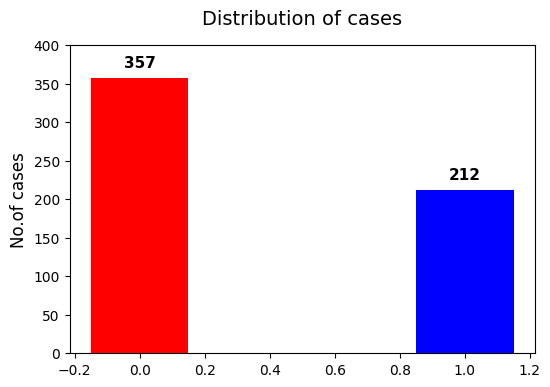

In [10]:
from os import altsep
from matplotlib.typing import LineStyleType
# Class distribution after remapping
### CODE HERE ###
import matplotlib.pyplot as plt

counts_remap = y_remap.value_counts()
#print(counts_remap)

# Create the bar plot
plt.figure(figsize=(6,4))
#bars = plt.bar(categories, counts1 , color=['red','blue'], width=0.6)
bars = plt.bar(counts_remap.index.get_level_values(0).tolist(), counts_remap.values.tolist() , color=['red','blue'], width=0.3)


#enhance the plot
plt.title('Distribution of cases',fontsize=14, pad=15)
plt.ylabel('No.of cases', fontsize=12)
plt.ylim(0,400)
#plt.grid(axis='y',Linestyle='--', alpha=0.5)

#add value labels on top of each bar
for bar in bars:
  yval = bar.get_height()
  plt.text(bar.get_x() + bar.get_width()/2, yval +10 , f'{yval}', ha='center', va='bottom' , fontsize=11, fontweight='bold')

plt.show()


### 2.4 Feature Distributions <font color="red">[2 marks]</font>

Pick 4-6 features and plot their distributions using histograms or boxplots. Look for skewness, outliers, and whether the two classes separate visually on any feature.


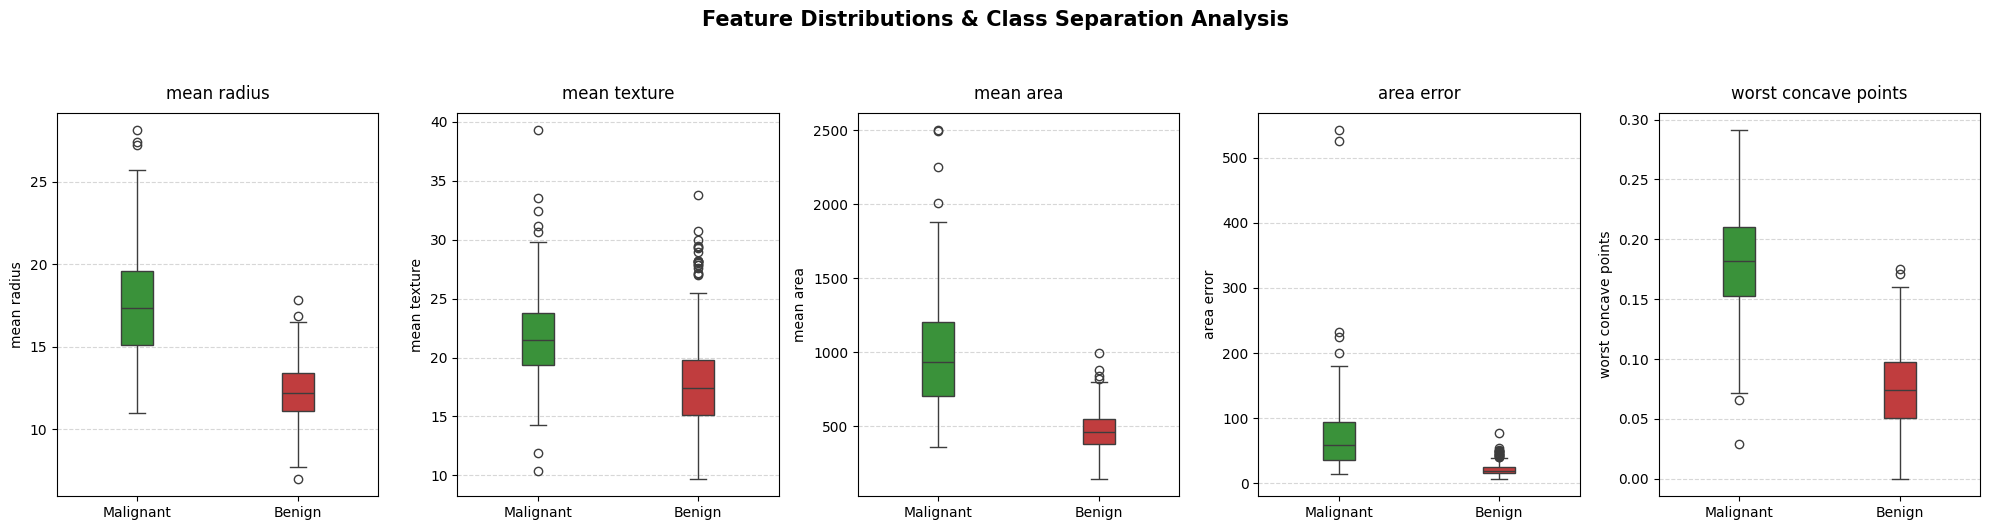

In [11]:
# Feature distributions for 6 selected features, coloured by class
### CODE HERE ###
import seaborn as sns

# 1. select 5 features to analyze
sel_features = [
    "mean radius",
    "mean texture",
    "mean area",
    "area error",
    "worst concave points"
]

# 2. Combine features and remapped target into a temporary plotting DataFrame
plot_df=df[sel_features].copy()
plot_df['Diagnosis'] = y_remap['target'].map({0:'Benign',1:'Malignant'})

# 3. Set up a grid of box plots (1 row, 5 columns)
fig,axes = plt.subplots(1,5,figsize=(20,5))
fig.suptitle('Feature Distributions & Class Separation Analysis', fontsize=15, weight='bold', y=1.05)

# 4. Loop through features and generate a boxplot for each
for i, feature in enumerate(sel_features):
  sns.boxplot(
      data=plot_df,
      x='Diagnosis',
      y=feature,
      ax=axes[i],
      palette = ['#2ca02c', '#d62728'],
      hue='Diagnosis',
      legend=False,
      width=0.2
  )
  axes[i].set_title(feature, fontsize=12, pad=10)
  axes[i].set_xlabel('')
  axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



### ✍️ Interpretation Checkpoint

**[Your Answer]:** Answer these questions in 2-3 sentences each:
1. Is the dataset balanced? How might imbalance affect model training?
2. Do the features have similar scales? What does this mean for models like KNN and SVM?
3. Why is recall a better primary metric than accuracy for this problem?
4. Why must we fit the scaler on training data only and not on the full dataset? What information from the test set would leak into training if we did?


*Write your answers here:*

1. ***No. dataset is not balanced. imbalance figures effects data analysis and visualizaion and get into over fitting or under fitting***

2. ***No. few features have data not in scale with othe features. for example, mean are, area error, worst permeter, worst area have extreme high values compared to other features. KNN and SVM models are based on distance would give poor performance***

3. ***beacause, the cost of a False Negative (missing a malignant tumor) is catastrophic, potentially leading to a loss of life***

4. ***We must use fit on training set only. data leakage occurs when  information from outside the training set is used to learn the model, making it overly optimistic and unrealistic***


## Stage 3: Data Preprocessing and Preparation

<font color="red">**[7 marks]**</font>


### 3.1 Missing Value Audit <font color="red">[1 mark]</font>

Confirm no missing values exist. If any do, handle them with median imputation.


In [12]:
# Missing value audit
### CODE HERE ###
print(df.isnull().sum().sum())  # 0

# No missing values found.
# just displaying sample code here
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
df_imputed = imputer.fit_transform(df)


0


### 3.2 Train-Test Split <font color="red">[2 marks]</font>

Split into 70% training and 30% test using **stratified sampling** to preserve the class ratio to mitigate any slight class imbalance. Use `random_state=42`.


In [13]:
# Stratified train-test split
### CODE HERE ###
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df, y_remap, test_size=0.3, random_state=42, stratify=y)


### 3.3 Feature Scaling <font color="red">[2 marks]</font>

Apply `StandardScaler`. **Fit the scaler on training data only**, then transform both train and test sets. If you fit on the full dataset, the scaler learns the mean and standard deviation of the test data, which inflates your results. That is data leakage.

> **Note:** Decision Trees split on thresholds and don't need scaling. But for consistency here, we scale for all models.


In [14]:
# Feature scaling: fit on train only, transform both
### CODE HERE ###

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled= scaler.transform(X_test)


### 3.4 Confirm Prepared Data <font color="red">[2 marks]</font>

Print shapes of your final training and test sets. Verify the class distribution is preserved in both.


In [15]:
# Confirm prepared data
### CODE HERE ###
#  Print Shapes of the final sets
print(X_train_scaled.shape)
print(X_test_scaled.shape)

# Calculate distributions for Training Set
#y_train_cnts = y_train.value_counts()
train_pct = y_train.value_counts(normalize=True)*100

# Calculate distributions for Test Set
#test_counts = y_test.value_counts()
test_pct = y_test.value_counts(normalize=True) * 100

print(train_pct, test_pct )

(398, 30)
(171, 30)
target
0         62.81407
1         37.18593
Name: proportion, dtype: float64 target
0         62.573099
1         37.426901
Name: proportion, dtype: float64


## Helper: Evaluation Function

You will evaluate many models. Rather than copy-pasting the same five lines every time, define a reusable function. Call it throughout Stages 4-6.


In [33]:
# Helper function. Use this to evaluate all models consistently.
### CODE HERE ###

#import metrics
from sklearn.metrics import classification_report, confusion_matrix, recall_score

def evaluate_model(model, X_test, y_test, model_name):
  #model predictions
  y_pred= model.predict(X_test)

  #calc recall
  pri_recall = recall_score(y_test,y_pred, pos_label=1)

  print("=" * 60)
  print(f"PERFORMANCE REPORT FOR: {model_name.upper()}")
  print("=" * 60)
  print(f"PRIMARY CRITICAL METRIC -> Recall (Catch Rate): {pri_recall:.2%}")
  print("-" * 60)

  # 3. Print the full suite of metrics (Precision, F1-Score, Accuracy)
  print("Detailed Classification Summary:")
  print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malignant (1)']))
  print("-" * 60)

  # 4. Generate and plot a beautifully styled Confusion Matrix
  cm = confusion_matrix(y_test, y_pred)

  plt.figure(figsize=(5, 4))
  sns.heatmap(
      cm,
      annot=True,
      fmt='d',
      cmap='Blues',
      xticklabels=['Predicted Benign', 'Predicted Malignant'],
      yticklabels=['Actual Benign', 'Actual Malignant'],
      cbar=False
  )

  plt.title(f'{model_name} Confusion Matrix', fontsize=13, pad=12, weight='bold')
  plt.tight_layout()
  plt.show()

  metrics = {
        'Model': model_name,
        'Recall (Catch Rate)': recall_score(y_test, y_pred, pos_label=1),
        'Precision': precision_score(y_test, y_pred, pos_label=1),
        'F1-Score': f1_score(y_test, y_pred, pos_label=1),
        'Accuracy': accuracy_score(y_test, y_pred)
    }

  return metrics

## How GridSearchCV Works

If you haven't used `GridSearchCV` before, read this before moving on.

`GridSearchCV` automates hyperparameter tuning. You give it a set of parameter values to try, and it trains a model for every combination, scores each one using cross-validation, and tells you which combination won.

You can refer to the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)

Here is the pattern you will repeat for every model below:

```python
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# 1. Define what parameter values to try
param_grid = {'C': [0.1, 1, 10]}

# 2. Set up GridSearchCV
grid = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=10000),
    param_grid=param_grid,
    scoring='recall',   # what metric to optimise
    cv=5,               # 5-fold cross-validation on training data
    n_jobs=-1            # use all CPU cores
)

# 3. Fit on training data
grid.fit(X_train_scaled, y_train)

# 4. Check results
print("Best parameters:", grid.best_params_)
print("Best CV recall:", grid.best_score_)
best_model = grid.best_estimator_

# 5. Predict on test set
y_pred = best_model.predict(X_test_scaled)
```

Every model below follows the same five steps. The only things that change are the estimator and the parameter grid.


## Stage 4: Model Training, Hyperparameter Tuning, and Evaluation

<font color="red">**[23 marks]**</font>

Train **four classifiers**, tune them, evaluate each one.

For each model:
1. Define the parameter grid
2. Run `GridSearchCV` with `scoring='recall'`, `cv=5`
3. Print the best parameters
4. Predict on the test set using the best estimator
5. Evaluate using `evaluate_model()`

> We use `scoring='recall'` because our goal is to catch malignant cases. Accuracy is misleading when classes are imbalanced.



### 4.1 Logistic Regression (Baseline) <font color="red">[5 marks]</font>

Logistic Regression with `class_weight='balanced'` to handle class imbalance.

**Hyperparameters to tune:**
- `C`: Regularisation strength. Try `[0.01, 0.1, 1, 10, 100]`
- Set `max_iter=10000` and `random_state=42`


In [34]:
#define GridSearchCV helper
from sklearn.model_selection import GridSearchCV

def grid_searchCV_helper(model, param_grid, X_train, y_train, scoring, cv=5):
  grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        verbose=1
    )
   # Run the grid search on the training data
  grid_search.fit(X_train, y_train)
  print("\nTuning Complete!")
  print(f"Best Parameters Found: {grid_search.best_params_}")
  print(f"Best Validation {scoring.capitalize()} Score: {grid_search.best_score_:.2%}")
  print("-" * 60)

  # Return the best tuned estimator model
  return grid_search.best_estimator_




In [18]:
## Logistic Regression with GridSearchCV
### CODE HERE ###
from sklearn.linear_model import LogisticRegression

param_grid = {'C': [0.1, 1, 10]}
log_reg = LogisticRegression( random_state=42)

grid_log_reg = grid_searchCV_helper(
    model=log_reg,
    param_grid=param_grid,
    X_train=X_train_scaled,
    y_train=y_train,
    scoring='recall'
)

Fitting 5 folds for each of 3 candidates, totalling 15 fits

✅ Tuning Complete!
🥇 Best Parameters Found: {'C': 1}
📈 Best Validation Recall Score: 95.98%
------------------------------------------------------------


PERFORMANCE REPORT FOR: GRIDSEARCHCV - LOGISTIC REGRESSION
PRIMARY CRITICAL METRIC -> Recall (Catch Rate): 98.44%
------------------------------------------------------------
Detailed Classification Summary:
               precision    recall  f1-score   support

   Benign (0)       0.99      0.99      0.99       107
Malignant (1)       0.98      0.98      0.98        64

     accuracy                           0.99       171
    macro avg       0.99      0.99      0.99       171
 weighted avg       0.99      0.99      0.99       171

------------------------------------------------------------


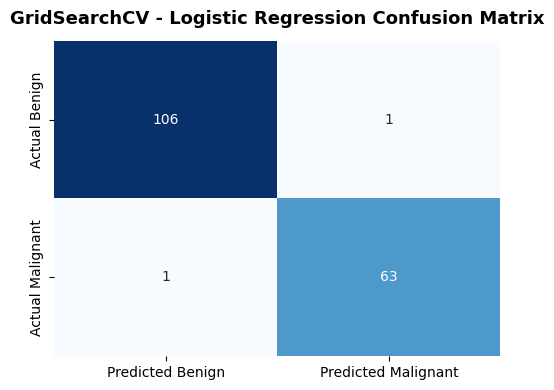

{'Model': 'GridSearchCV - Logistic Regression', 'Recall (Catch Rate)': 0.984375, 'Precision': 0.984375, 'F1-Score': 0.984375, 'Accuracy': 0.9883040935672515}


In [36]:
# Evaluate LR on test set
### CODE HERE ###
# 4. Pass the final tuned model into your evaluate_classifier helper function
log_reg_metrics = evaluate_model(
    model=grid_log_reg,
    X_test=X_test_scaled,
    y_test=y_test,
    model_name="GridSearchCV - Logistic Regression"
)

print(log_reg_metrics)

### 4.2 K-Nearest Neighbours (KNN) <font color="red">[6 marks]</font>

[KNN](https://scikit-learn.org/stable/modules/neighbors.html) classifies a sample by majority vote of its nearest neighbours. Sensitive to feature scale, which is why we scaled the data.

**Hyperparameters to tune:**
- `n_neighbors`: Try `[3, 5, 7, 9, 11, 15]`
- `weights`: Try `['uniform', 'distance']`. Uniform gives equal votes. Distance gives closer neighbours more influence.

> Think about it: if malignant samples are sparse in a local neighbourhood, why might `weights='distance'` help?


In [25]:
# KNN with GridSearchCV
### CODE HERE ###

from sklearn.neighbors import KNeighborsClassifier

#initialize the model
knn = KNeighborsClassifier()

#define the parameter grid
param_grid = {
    "n_neighbors":[3,5,7,9,11,13,15],
    'weights':['uniform', 'distance'],
    'metric':['euclidean', 'manhattan']
}


grid_knn = grid_searchCV_helper(
    model=knn,
    param_grid=param_grid,
    X_train=X_train_scaled,
    y_train=y_train,
    scoring='recall'
)

Fitting 5 folds for each of 28 candidates, totalling 140 fits

✅ Tuning Complete!
🥇 Best Parameters Found: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
📈 Best Validation Recall Score: 94.64%
------------------------------------------------------------


PERFORMANCE REPORT FOR: GRIDSEARCHCV - KNN
PRIMARY CRITICAL METRIC -> Recall (Catch Rate): 92.19%
------------------------------------------------------------
Detailed Classification Summary:
               precision    recall  f1-score   support

   Benign (0)       0.95      0.98      0.97       107
Malignant (1)       0.97      0.92      0.94        64

     accuracy                           0.96       171
    macro avg       0.96      0.95      0.96       171
 weighted avg       0.96      0.96      0.96       171

------------------------------------------------------------


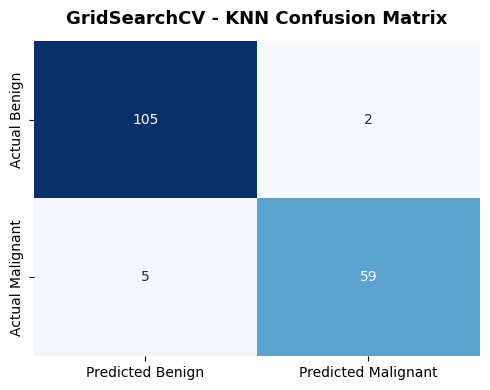

In [37]:
# Evaluate KNN on test set
### CODE HERE ###

knn_metrics = evaluate_model(
    model=grid_knn,
    X_test=X_test_scaled,
    y_test=y_test,
    model_name="GridSearchCV - KNN"
)

### 4.3 Decision Tree <font color="red">[6 marks]</font>

[Decision Trees](https://scikit-learn.org/stable/modules/tree.html) split features at thresholds. Without constraints, they memorise training data perfectly and fail on new data. That is overfitting.

**Hyperparameters to tune:**
- `max_depth`: Try `[3, 5, 7, 10, None]`. `None` means no limit.
- `min_samples_split`: Try `[2, 5, 10]`
- `min_samples_leaf`: Try `[1, 2, 4]`
- Use `class_weight='balanced'` and `random_state=42`


In [28]:
# Decision Tree with GridSearchCV
### CODE HERE ###

from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(random_state=42,class_weight='balanced')

dtc_param_grid={
    'criterion' :['gini','entropy'],
    'max_depth' :[3, 5, 7, 10, None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

grid_dtc = grid_searchCV_helper(
    model=dtc,
    param_grid=dtc_param_grid,
    X_train=X_train,
    y_train=y_train,
    scoring='recall'
)

Fitting 5 folds for each of 90 candidates, totalling 450 fits

✅ Tuning Complete!
🥇 Best Parameters Found: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
📈 Best Validation Recall Score: 95.29%
------------------------------------------------------------


PERFORMANCE REPORT FOR: GRIDSEARCHCV - DECISION TREE CLASSIFIER
PRIMARY CRITICAL METRIC -> Recall (Catch Rate): 92.19%
------------------------------------------------------------
Detailed Classification Summary:
               precision    recall  f1-score   support

   Benign (0)       0.95      0.95      0.95       107
Malignant (1)       0.92      0.92      0.92        64

     accuracy                           0.94       171
    macro avg       0.94      0.94      0.94       171
 weighted avg       0.94      0.94      0.94       171

------------------------------------------------------------


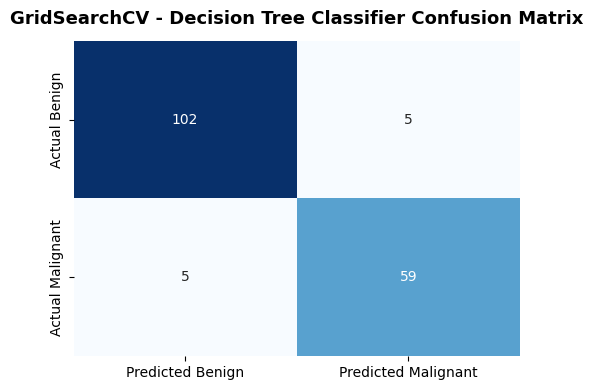

In [38]:
# Evaluate Decision Tree on test set
### CODE HERE ###

dtc_metrics = evaluate_model(
    model=grid_dtc,
    X_test=X_test,
    y_test=y_test,
    model_name="GridSearchCV - Decision Tree Classifier"
)

### 4.4 Support Vector Machine (SVM) <font color="red">[6 marks]</font>

[SVMs](https://scikit-learn.org/stable/modules/svm.html) find the hyperplane that separates classes with the widest margin. With kernel functions, they can model non-linear boundaries.

**Hyperparameters to tune:**
- `C`: Try `[0.1, 1, 10]`
- `kernel`: Try `['linear', 'rbf']`. Linear for linearly separable data, RBF for non-linear.
- `gamma`: Try `['scale', 'auto']` (matters for RBF kernel)
- Use `class_weight='balanced'`, `random_state=42`, and `probability=True`

> **Why `probability=True`?** We need `predict_proba()` for threshold tuning in Stage 6.


In [30]:
# SVM with GridSearchCV
### CODE HERE ###
from sklearn.svm import SVC

svm_model= SVC(random_state=42, class_weight='balanced' , probability=True)


svm_param_grid={
    'C' :[0.1,1,10],
    'kernel' :['linear','rbf'],
    'gamma':['scale','auto']
}

grid_svm = grid_searchCV_helper(
    model=svm_model,
    param_grid=svm_param_grid,
    X_train=X_train_scaled,
    y_train=y_train,
    scoring='recall'
)


Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ Tuning Complete!
🥇 Best Parameters Found: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
📈 Best Validation Recall Score: 96.00%
------------------------------------------------------------


PERFORMANCE REPORT FOR: GRIDSEARCHCV - SUPPORT VECTOR MACHINE
PRIMARY CRITICAL METRIC -> Recall (Catch Rate): 96.88%
------------------------------------------------------------
Detailed Classification Summary:
               precision    recall  f1-score   support

   Benign (0)       0.98      0.96      0.97       107
Malignant (1)       0.94      0.97      0.95        64

     accuracy                           0.96       171
    macro avg       0.96      0.97      0.96       171
 weighted avg       0.97      0.96      0.97       171

------------------------------------------------------------


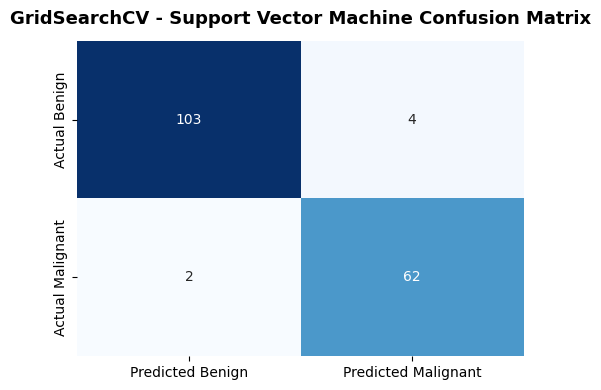

In [39]:
# Evaluate SVM on test set
### CODE HERE ###

svm_metrics = evaluate_model(
    model=grid_svm,
    X_test=X_test_scaled,
    y_test=y_test,
    model_name="GridSearchCV - Support Vector Machine"
)

## Stage 5: Model Comparison

<font color="red">**[9 marks]**</font>


### 5.1 Build a Comparison Table <font color="red">[3 marks]</font>

Create a DataFrame comparing all four models on the **test set**:
- Accuracy
- Recall (for malignant class)
- Precision (for malignant class)
- F1-Score (for malignant class)
- Number of False Negatives (from confusion matrix)

> **Hint:** A false negative is a malignant case predicted as benign. In the confusion matrix, it sits at position `[1][0]` when malignant = 1.


In [40]:
# Comparison table for all 4 models
### CODE HERE ###

results=[log_reg_metrics, knn_metrics, dtc_metrics, svm_metrics]

#build and display comparision table

compare_df = pd.DataFrame(results)
metric_cols = ['Recall (Catch Rate)', 'Precision', 'F1-Score', 'Accuracy']
compare_df[metric_cols] = compare_df[metric_cols].map(lambda x: f"{x:.2%}")

#Sort by your primary critical metric
compare_df = compare_df.sort_values(by='Recall (Catch Rate)', ascending=False).reset_index(drop=True)

print("\n FINAL MODEL COMPARISON LEADERBOARD:")
print(compare_df.to_markdown(index=False))



 FINAL MODEL COMPARISON LEADERBOARD:
| Model                                   | Recall (Catch Rate)   | Precision   | F1-Score   | Accuracy   |
|:----------------------------------------|:----------------------|:------------|:-----------|:-----------|
| GridSearchCV - Logistic Regression      | 98.44%                | 98.44%      | 98.44%     | 98.83%     |
| GridSearchCV - Support Vector Machine   | 96.88%                | 93.94%      | 95.38%     | 96.49%     |
| GridSearchCV - KNN                      | 92.19%                | 96.72%      | 94.40%     | 95.91%     |
| GridSearchCV - Decision Tree Classifier | 92.19%                | 92.19%      | 92.19%     | 94.15%     |


### 5.2 Visualise Comparison <font color="red">[2 marks]</font>

Create a grouped bar chart comparing Recall and Precision across all four models.


container---<BarContainer object of 4 artists>
container---<BarContainer object of 4 artists>


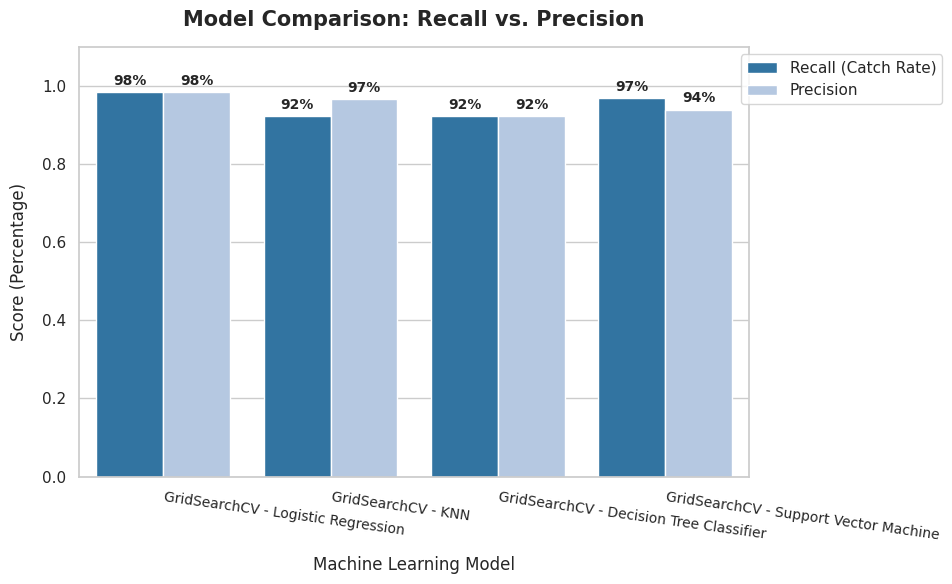

In [82]:
# Grouped bar chart: Recall and Precision
### CODE HERE ###


# 1. Convert the raw numerical results list to a DataFrame
raw_comparison_df = pd.DataFrame(results)

# 2. Transform data from Wide to Long format for Seaborn grouping
# This collapses 'Recall' and 'Precision' columns into a single column
df_long = pd.melt(
    raw_comparison_df,
    id_vars=['Model'],
    value_vars=['Recall (Catch Rate)', 'Precision'],
    var_name='Metric',
    value_name='Score'
)

# 3. Set up the plotting style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 4. Create the grouped bar chart
ax = sns.barplot(
    data=df_long,
    x='Model',
    y='Score',
    hue='Metric',
    palette=['#1f77b4', '#aec7e8']  # Navy/Blue tone for contrast
)

# 5. Add value labels on top of each bar
for container in ax.containers:
  raw_values = container.datavalues
  formatted_labels = [f"{v*100:.0f}%" for v in raw_values]
  ax.bar_label(container, labels=formatted_labels, padding=3, fontsize=10, weight='bold')

# 6. Customize titles and labels
plt.title('Model Comparison: Recall vs. Precision', fontsize=15, pad=15, weight='bold')
plt.xlabel('Machine Learning Model', fontsize=12, labelpad=10)
plt.ylabel('Score (Percentage)', fontsize=12, labelpad=10)
plt.ylim(0, 1.1)  # Leave room at the top for labels
plt.xticks(rotation=-8, ha='left', fontsize=10)
# Clean up layout and display
plt.legend(loc='upper right', frameon=True,bbox_to_anchor=(1.3, 1))
plt.tight_layout()
plt.show()


### 5.3 Cross-Validation Stability <font color="red">[2 marks]</font>

For **all four models**, run 5-fold stratified [cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html) on the **training set** using `cross_val_score` with `scoring='recall'`. Print the mean and standard deviation of recall for each.

> **Why this matters:** High recall on one split means nothing if the model collapses on another. Stability tells you whether you can trust the number.

> **A caveat:** You are running `cross_val_score` on already-tuned estimators. This is a quick stability check, not a substitute for nested cross-validation. Good enough for a practice exercise.


In [86]:
# Cross-validation stability for all 4 models
### CODE HERE ###

from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. Define the 5-Fold Stratified Cross-Validation split strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models= [log_reg, dtc, knn, svm_model]
stability_results = []

print("🔄 Computing Stratified 5-Fold Cross-Validation Stability...")

# 2. Iterate through each tuned model to measure distribution scores
for model in models:

    # Run cross_val_score on the raw training set (Pipelines handle scaling implicitly inside each fold)
    cv_scores = cross_val_score(
        estimator=model,
        X=X_train,
        y=y_train,
        scoring='recall',
        cv=cv_strategy,
        n_jobs=-1
    )

    # 3. Save raw statistics to our list
    stability_results.append({
        'Model': model,
        'Mean Recall': cv_scores.mean(),
        'Std Deviation': cv_scores.std(),
        'Min Score (Worst Fold)': cv_scores.min(),
        'Max Score (Best Fold)': cv_scores.max()
    })

# --- [Step 4: Build & Format Stability Table] ---
stability_df = pd.DataFrame(stability_results)

# Sort models by lowest Standard Deviation (Most stable model on top)
stability_df = stability_df.sort_values(by='Std Deviation', ascending=True).reset_index(drop=True)

# Format float variables into easily scannable text percentages
percentage_cols = ['Mean Recall', 'Std Deviation', 'Min Score (Worst Fold)', 'Max Score (Best Fold)']
for col in percentage_cols:
    stability_df[col] = stability_df[col].map(lambda x: f"{x:.2%}")

print("\n CROSS-VALIDATION STABILITY REPORT:")
print(stability_df.to_markdown(index=False))


🔄 Computing Stratified 5-Fold Cross-Validation Stability...

 CROSS-VALIDATION STABILITY REPORT:
| Model                                                            | Mean Recall   | Std Deviation   | Min Score (Worst Fold)   | Max Score (Best Fold)   |
|:-----------------------------------------------------------------|:--------------|:----------------|:-------------------------|:------------------------|
| SVC(class_weight='balanced', probability=True, random_state=42)  | 86.46%        | 4.39%           | 79.31%                   | 90.00%                  |
| KNeighborsClassifier()                                           | 87.82%        | 4.72%           | 79.31%                   | 93.10%                  |
| DecisionTreeClassifier(class_weight='balanced', random_state=42) | 91.93%        | 5.84%           | 83.33%                   | 100.00%                 |
| LogisticRegression(random_state=42)                              | 91.26%        | 6.55%           | 80.00%              

### 5.4 Feature Importance <font color="red">[2 marks]</font>

Knowing *which features drive predictions* matters as much as the predictions themselves.

- Extract **feature importances** from your best Decision Tree (`.feature_importances_`) or **coefficients** from Logistic Regression (`.coef_[0]`)
- Plot the **top 10 most important features** as a horizontal bar chart


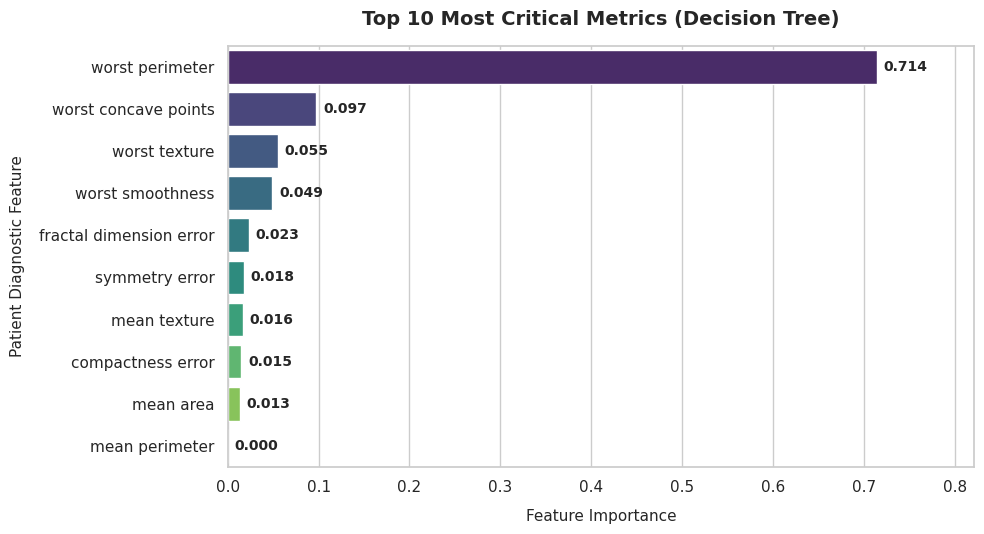

In [104]:
# Feature importance from Decision Tree
### CODE HERE ###
feature_names = data.feature_names
chosen_model_name = "Decision Tree"

if chosen_model_name == 'Decision Tree':
    # Access the classifier step ('clf') inside the pipeline
    raw_weights = grid_dtc.feature_importances_
    title_label = "Feature Importance"
else:
    # Access coefficients and take absolute values for impact magnitude
    raw_weights = np.abs(grid_log_reg.coef_[0])
    title_label = "Absolute Coefficient Magnitude"


 #Pair weights with feature names and convert to a sorted DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': raw_weights
}).sort_values(by='Importance', ascending=False)

#Filter for only the top 10 most impactful features
top_10_features = importance_df.head(10)

#[Step 5: Plotting the Horizontal Bar Chart] ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5.5))

# Horizontal bar plot (y=Feature, x=Importance) makes long text names easy to read
ax = sns.barplot(
    data=top_10_features,
    x='Importance',
    y='Feature',
    palette='viridis' # Clean sequential color spectrum
)

# Add clean numerical data labels on the tips of the bars
for container in ax.containers:
    # Use 3 decimal points for precision in tiny fractional importance weights
    ax.bar_label(container, fmt='%.3f', padding=5, fontsize=10, weight='bold')

# Customize chart text properties
plt.title(f'Top 10 Most Critical Metrics ({chosen_model_name})', fontsize=14, pad=15, weight='bold')
plt.xlabel(title_label, fontsize=11, labelpad=10)
plt.ylabel('Patient Diagnostic Feature', fontsize=11, labelpad=10)

# Leave space on the right margin so data labels aren't clipped
plt.xlim(0, top_10_features['Importance'].max() * 1.15)

plt.tight_layout()
plt.show()

## Stage 6: Final Model Selection

<font color="red">**[5 marks]**</font>


### 6.1 Threshold Tuning <font color="red">[2 marks]</font>

By default, classifiers use a probability threshold of 0.5 to assign classes. For medical diagnosis, we can lower this threshold to catch more malignant cases (higher recall) at the cost of more false positives (lower precision).

**Steps:**
1. Create a **stratified validation split from your training data** (70/30 from `X_train_scaled`). Do not touch the test set for this.
2. Retrain your best model on the inner training portion
3. Get predicted probabilities on the validation portion using `predict_proba()`
4. Plot the **precision-recall curve**
5. Find a threshold where recall ≥ 0.95

> **Why not tune on the test set?** If you use the test set to pick a threshold, your final evaluation on that same test set is no longer honest. The test set becomes a tuning surface, and your reported metrics are optimistic.


In [ ]:
# Threshold tuning on a VALIDATION split (not test set)
# Step 1: Create inner split from training data
### CODE HERE ###

# Step 2: Retrain best model (SVM) on inner training set
### CODE HERE ###

# Step 3: Get predicted probabilities on validation set
### CODE HERE ###

# Step 4: Plot precision-recall curve
### CODE HERE ###

# Step 5: Find threshold where recall >= 0.95
### CODE HERE ###


### 6.2 Final Recommendation <font color="red">[3 marks]</font>

**[Your Answer]:** Answer the following. Cite specific numbers from your results.

1. Which model do you recommend and why? Reference its recall, false negative count, and cross-validation stability.
2. How many false negatives does it produce on the test set? Is this clinically acceptable?
3. What is one specific limitation of your analysis? (Not "more data." Be concrete, e.g., "the dataset has only 569 samples, which limits the reliability of cross-validation estimates.")


*Write your answers here:*

1. ***your answer here***

2. ***your answer here***

3. ***your answer here***


---
# PART 2: Multiclass Classification, Wine Dataset

## Context

The Wine dataset contains chemical analysis results of wines from the same region of Italy, grown from **three different cultivars** (grape varieties). The task: predict the cultivar (class 0, 1, or 2) based on 13 chemical attributes like alcohol content, malic acid, and flavanoids.

**Why Macro-F1 matters here:** No single wine class is more "dangerous" to misclassify. All three matter equally. Macro-averaged F1-score treats each class the same regardless of size.


## Stage 1: Data and Package Loading

<font color="red">**[2 marks]**</font>

Load the Wine dataset from `sklearn.datasets`. Convert to a DataFrame. Separate features and target. Import `MLPClassifier`.


In [ ]:
# Pre-imported for Part 2
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_wine

# Load wine dataset
wine_data = load_wine()
### CODE HERE ###


## Stage 2: Data Understanding

<font color="red">**[6 marks]**</font>


### 2.1 Basic Inspection <font color="red">[2 marks]</font>

Display the shape, first few rows, data types, and check for missing values.


In [ ]:
# Inspect the wine dataset
### CODE HERE ###


### 2.2 Class Distribution <font color="red">[2 marks]</font>

How many wines in each class? Visualise with a bar plot.


In [ ]:
# Wine class distribution
### CODE HERE ###


### 2.3 Feature Analysis <font color="red">[2 marks]</font>

Look at the feature ranges using `.describe()`. Some features range in the hundreds, others below 1. Then plot a **correlation heatmap** to see which features move together.


In [ ]:
# Summary statistics
### CODE HERE ###

# Correlation heatmap
### CODE HERE ###


### ✍️ Interpretation Checkpoint

**[Your Answer]:**
1. Are the three wine classes roughly balanced?
2. Looking at the feature ranges, do some features dominate others in scale? What does this imply for models like KNN and SVM?


*Write your answers here:*

1. ***your answer here***

2. ***your answer here***


## Stage 3: Data Preprocessing

<font color="red">**[4 marks]**</font>


### 3.1 Split and Scale <font color="red">[2 marks]</font>

Stratified train-test split (70-30, `random_state=42`), then `StandardScaler` fit on training data only. Stratification for handling any slight class imbalance in the data.

> **Reminder:** Decision Trees don't need scaling, but KNN, SVM, MLP, and Logistic Regression all do. We scale for all models here.


In [ ]:
# Stratified train-test split
### CODE HERE ###


In [ ]:
# Scale features: fit on train, transform both
### CODE HERE ###


### 3.2 Verify Preparation <font color="red">[2 marks]</font>

Print shapes and class distributions for both splits.


In [ ]:
# Verify preparation
### CODE HERE ###


## Stage 4: Model Training and Hyperparameter Tuning

<font color="red">**[20 marks]**</font>

Train **five classifiers** on the wine dataset. Use `GridSearchCV` with `scoring='f1_macro'` and `cv=5` for each. Use the `evaluate_model()` helper from Part 1.

> **Key difference from Part 1:** We optimise for `f1_macro` instead of `recall`, because all classes matter equally.


### 4.1 Logistic Regression <font color="red">[3 marks]</font>

**Hyperparameters:**
- `C`: `[0.01, 0.1, 1, 10]`
- `max_iter`: `10000`
- `random_state`: `42`


In [ ]:
# Logistic Regression for Wine
### CODE HERE ###


### 4.2 K-Nearest Neighbours <font color="red">[3 marks]</font>

**Hyperparameters:**
- `n_neighbors`: `[3, 5, 7, 9, 11]`
- `weights`: `['uniform', 'distance']`


In [ ]:
# KNN for Wine
### CODE HERE ###


### 4.3 Decision Tree <font color="red">[3 marks]</font>

**Hyperparameters:**
- `max_depth`: `[3, 5, 7, 10, None]`
- `min_samples_split`: `[2, 5, 10]`
- `min_samples_leaf`: `[1, 2, 4]`
- `random_state`: `42`


In [ ]:
# Decision Tree for Wine
### CODE HERE ###


### 4.4 Support Vector Machine <font color="red">[3 marks]</font>

**Hyperparameters:**
- `C`: `[0.1, 1, 10]`
- `kernel`: `['linear', 'rbf']`
- `gamma`: `['scale', 'auto']`
- `random_state`: `42`


In [ ]:
# SVM for Wine
### CODE HERE ###


### 4.5 Multi-Layer Perceptron (MLP) <font color="red">[8 marks]</font>

The MLP is a neural network. Unlike the previous models, you control the **architecture**: how many layers, how many neurons per layer.

**Hyperparameters to tune:**
- `hidden_layer_sizes`: Try `[(50,), (100,), (50, 50), (100, 50)]`. Each tuple defines layer widths.
- `activation`: Try `['relu', 'tanh']`. The non-linear function at each neuron.
- `alpha`: Try `[0.0001, 0.001, 0.01]`. L2 regularisation to prevent overfitting.
- Set `max_iter=2000`, `random_state=42`, and `early_stopping=True`

> **What is early stopping?** It monitors validation performance during training and stops when performance plateaus. Without it, the network keeps training until it memorises the data.


In [ ]:
# MLP for Wine
### CODE HERE ###


In [ ]:
# Evaluate MLP on test set
### CODE HERE ###


### ✍️ MLP Interpretation

**[Your Answer]:**
1. What architecture (hidden layer sizes) performed best? Why do you think that configuration won?
2. Did the MLP outperform the classical models? By how much in macro-F1?
3. What role does `alpha` (regularisation) play? What happens if it is set too high? Too low?


*Write your answers here:*

1. ***your answer here***

2. ***your answer here***

3. ***your answer here***


## Stage 5: Model Comparison

<font color="red">**[8 marks]**</font>


### 5.1 Comparison Table <font color="red">[3 marks]</font>

Create a DataFrame comparing all five models on the **test set**:
- Accuracy
- Macro-Precision
- Macro-Recall
- Macro-F1-Score


In [ ]:
# Comparison table for all 5 wine models
### CODE HERE ###


### 5.2 Visualise Comparison <font color="red">[2 marks]</font>

Bar chart comparing Macro-F1 scores across all five models.


In [ ]:
# Macro-F1 bar chart
### CODE HERE ###


### 5.3 Cross-Validation Stability <font color="red">[3 marks]</font>

For **all five models**, run 5-fold cross-validation with `scoring='f1_macro'` on the training set. Print the mean and standard deviation for each.


In [ ]:
# Cross-validation stability for all 5 wine models
### CODE HERE ###


### ✍️ Classical vs Neural Comparison

**[Your Answer]:**
1. Which classical model performed best on macro-F1? Why might that be?
2. Did the MLP beat the classical models by a clear margin, or was the gap small?
3. When would you choose a simpler model like Logistic Regression over the MLP, even if the MLP scores slightly higher?


*Write your answers here:*

1. ***your answer here***

2. ***your answer here***

3. ***your answer here***


## Stage 6: Final Recommendation

<font color="red">**[5 marks]**</font>


### 6.1 Final Model Selection <font color="red">[3 marks]</font>

**[Your Answer]:**
1. Which model do you recommend as the best **classical** model for the wine dataset? Cite its macro-F1 score.
2. Which model do you recommend as the best **overall** model? Consider performance vs interpretability.
3. If a winemaker wanted to understand *why* a wine was classified as a certain cultivar, which model would you recommend and why?


*Write your answers here:*

1. ***your answer here***

2. ***your answer here***

3. ***your answer here***


### 6.2 Underfitting vs Overfitting Study <font color="red">[2 marks]</font>

Train three Decision Tree variants on the wine dataset:
1. `max_depth=1` with `random_state=42` (too simple, underfits)
2. `max_depth=None` with `random_state=42` (no constraints, overfits)
3. Your best tuned tree from Stage 4

For each, print the **training accuracy** and **test accuracy**. Look at the gap.


In [ ]:
# Overfitting study: 3 Decision Tree variants
### CODE HERE ###


### ✍️ Underfitting vs Overfitting

**[Your Answer]:**
1. Which variant underfits? How can you tell from the train/test accuracy?
2. Which variant overfits? What is the gap between train and test accuracy?
3. How does the tuned model sit between these two extremes?


*Write your answers here:*

1. ***your answer here***

2. ***your answer here***

3. ***your answer here***


---
## Indicative Mark Summary

> **Reminder:** These marks are for self-assessment only. They do not count towards your final grade.

| Section | Topic | Marks |
|---------|-------|-------|
| **Part 1** | | **55** |
| Stage 1 | Data Loading | 3 |
| Stage 2 | Data Understanding + Interpretation | 8 |
| Stage 3 | Preprocessing | 7 |
| Helper + Tutorial | Evaluation Function, GridSearchCV Walkthrough | 0 |
| Stage 4 | Model Training and Tuning (4 models) | 23 |
| Stage 5 | Model Comparison + Feature Importance | 9 |
| Stage 6 | Final Model Selection | 5 |
| **Part 2** | | **45** |
| Stage 1 | Data Loading | 2 |
| Stage 2 | Data Understanding + Interpretation | 6 |
| Stage 3 | Preprocessing | 4 |
| Stage 4 | Model Training and Tuning (5 models, incl. MLP) | 20 |
| Stage 5 | Model Comparison | 8 |
| Stage 6 | Final Recommendation | 5 |
| | **Total** | **100** |

---
*End of Practice Assignment*
